# CIFAR-10 Image Classification: ANN vs CNN

**Goal:** Build image classifiers on CIFAR-10 using two families of architectures — a
plain fully-connected network (ANN) and convolutional networks (CNN) — then compare
them across architectures and training strategies (regularization, data augmentation,
optimizers, learning-rate scheduling).

**How to use this notebook**
- Runtime: `Runtime > Change runtime type > GPU` (T4 is enough).
- Everything below runs top-to-bottom. Training cells use modest epoch counts with
  `EarlyStopping` so the whole notebook finishes in well under an hour on a free Colab GPU.
- Every experiment writes its result into a shared `results` dict/table at the end so
  the final comparison is automatic, not manually copy-pasted.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


TensorFlow: 2.20.0
GPU available: []


## 2. Load & explore CIFAR-10

CIFAR-10: 60,000 32x32 RGB images, 10 balanced classes (50k train / 10k test).
It's small enough to train quickly but hard enough that a plain ANN clearly
underperforms a CNN — which is the whole point of this comparison.

In [5]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

print("Train:", x_train_full.shape, y_train_full.shape)
print("Test :", x_test.shape, y_test.shape)

# Hold out a validation set from training data
val_frac = 0.1
n_val = int(len(x_train_full) * val_frac)
idx = np.random.permutation(len(x_train_full))
val_idx, train_idx = idx[:n_val], idx[n_val:]

x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]

print("Split -> train:", x_train.shape[0], "val:", x_val.shape[0], "test:", x_test.shape[0])


  3948544/170498071 ━━━━━━━━━━━━━━━━━━━━ 49:16 18us/step

KeyboardInterrupt: 

NameError: name 'x_train' is not defined

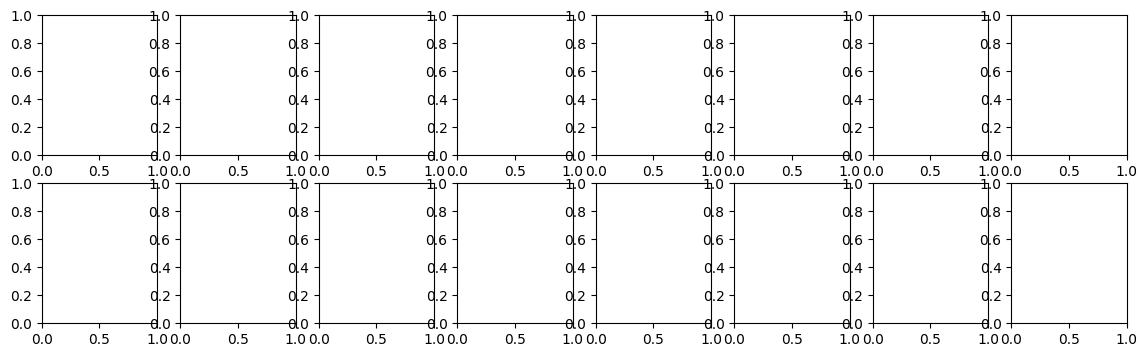

In [4]:
# Visualize a few samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 images")
plt.tight_layout()
plt.show()

# Class balance check
vals, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(8,3))
plt.bar([CLASS_NAMES[v] for v in vals], counts)
plt.xticks(rotation=45)
plt.title("Class distribution (train)")
plt.tight_layout()
plt.show()


## 3. Preprocessing

- Scale pixels to [0, 1].
- One-hot encode labels (we'll train with `categorical_crossentropy` so the same
  label tensors work for both softmax models and let us reuse `classification_report`
  cleanly).
- Keep an un-flattened (32,32,3) version for CNNs and a flattened (3072,) version for
  the ANN, both built from the *same* underlying pixel data so the comparison is fair.

In [ ]:
def preprocess(x):
    return x.astype('float32') / 255.0

x_train_p = preprocess(x_train)
x_val_p   = preprocess(x_val)
x_test_p  = preprocess(x_test)

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_val_oh   = keras.utils.to_categorical(y_val, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)

INPUT_SHAPE = x_train_p.shape[1:]   # (32, 32, 3)
print(INPUT_SHAPE)


## 4. Shared training/evaluation harness

One helper trains a model and logs everything we need for the final comparison table:
parameter count, training time, best val accuracy, test accuracy/loss.

In [ ]:
results = []
def compile_and_train(model, name, x_tr, y_tr, x_va, y_va, epochs=30, batch_size=128,
                       optimizer='adam', datagen=None, extra_callbacks=None, verbose=0):
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    cbs = [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
    if extra_callbacks:
        cbs += extra_callbacks

    start = time.time()
    if datagen is not None:
        history = model.fit(datagen.flow(x_tr, y_tr, batch_size=batch_size),
                             steps_per_epoch=len(x_tr) // batch_size,
                             validation_data=(x_va, y_va),
                             epochs=epochs, callbacks=cbs, verbose=verbose)
    else:
        history = model.fit(x_tr, y_tr, validation_data=(x_va, y_va),
                             epochs=epochs, batch_size=batch_size,
                             callbacks=cbs, verbose=verbose)
    train_time = time.time() - start

    test_loss, test_acc = model.evaluate(x_test_p if x_tr.ndim == 4 else x_test_p.reshape(len(x_test_p), -1),
                                          y_test_oh, verbose=0)

    n_params = model.count_params()
    best_val_acc = max(history.history['val_accuracy'])

    results.append({
        'model': name,
        'params': n_params,
        'epochs_run': len(history.history['loss']),
        'train_time_sec': round(train_time, 1),
        'best_val_acc': round(best_val_acc, 4),
        'test_acc': round(test_acc, 4),
        'test_loss': round(test_loss, 4),
    })
    print(f"[{name}] params={n_params:,}  time={train_time:.1f}s  "
          f"val_acc={best_val_acc:.4f}  test_acc={test_acc:.4f}")
    return model, history

def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(history.history['accuracy'], label='train')
    ax[0].plot(history.history['val_accuracy'], label='val')
    ax[0].set_title(f'{title} - Accuracy'); ax[0].legend(); ax[0].set_xlabel('epoch')
    ax[1].plot(history.history['loss'], label='train')
    ax[1].plot(history.history['val_loss'], label='val')
    ax[1].set_title(f'{title} - Loss'); ax[1].legend(); ax[1].set_xlabel('epoch')
    plt.tight_layout(); plt.show()


## 5. Part A — ANN (fully-connected) models

An ANN has to flatten the image into a 3072-length vector, throwing away all spatial
structure (a pixel and its neighbor become unrelated inputs). Two variants:

1. **Baseline ANN** — plain `Dense` stack, no regularization.
2. **Regularized ANN** — deeper, with `BatchNormalization` + `Dropout`, to see how much
   regularization alone can close the gap (spoiler: not much, because the architecture
   itself is the bottleneck, not overfitting).

In [ ]:
x_train_flat = x_train_p.reshape(len(x_train_p), -1)
x_val_flat   = x_val_p.reshape(len(x_val_p), -1)
x_test_flat  = x_test_p.reshape(len(x_test_p), -1)

def build_ann_baseline():
    model = models.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ], name='ANN_baseline')
    return model

ann_base = build_ann_baseline()
ann_base.summary()


In [ ]:
ann_base, hist_ann_base = compile_and_train(
    ann_base, 'ANN_baseline', x_train_flat, y_train_oh, x_val_flat, y_val_oh,
    epochs=30, verbose=1)
plot_history(hist_ann_base, 'ANN baseline')


In [ ]:
def build_ann_regularized():
    model = models.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(1024), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(512),  layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(256),  layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ], name='ANN_regularized')
    return model

ann_reg = build_ann_regularized()
ann_reg, hist_ann_reg = compile_and_train(
    ann_reg, 'ANN_regularized', x_train_flat, y_train_oh, x_val_flat, y_val_oh,
    epochs=40, verbose=1)
plot_history(hist_ann_reg, 'ANN regularized')


## 6. Part B — CNN models

CNNs keep the (32,32,3) structure. Convolution + weight sharing means the network
learns local, translation-invariant features (edges → textures → parts → objects)
instead of memorizing pixel positions. Three variants, each adding one training
strategy on top of the last so you can see the individual contribution:

1. **Baseline CNN** — plain conv/pool stack, no regularization.
2. **CNN + BatchNorm + Dropout** — standard regularization stack.
3. **CNN + BatchNorm + Dropout + Data Augmentation** — the full recipe.

In [ ]:
def build_cnn_baseline():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ], name='CNN_baseline')
    return model

cnn_base = build_cnn_baseline()
cnn_base.summary()


In [ ]:
cnn_base, hist_cnn_base = compile_and_train(
    cnn_base, 'CNN_baseline', x_train_p, y_train_oh, x_val_p, y_val_oh,
    epochs=30, verbose=1)
plot_history(hist_cnn_base, 'CNN baseline')


In [ ]:
def build_cnn_regularized():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2), layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2), layers.Dropout(0.3),

        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2), layers.Dropout(0.35),

        layers.Flatten(),
        layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.5),
        layers.Dense(10, activation='softmax'),
    ], name='CNN_regularized')
    return model

cnn_reg = build_cnn_regularized()
cnn_reg, hist_cnn_reg = compile_and_train(
    cnn_reg, 'CNN_regularized', x_train_p, y_train_oh, x_val_p, y_val_oh,
    epochs=40, verbose=1)
plot_history(hist_cnn_reg, 'CNN regularized')


In [ ]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)
datagen.fit(x_train_p)

cnn_aug = build_cnn_regularized()
cnn_aug._name = 'CNN_regularized_augmented'
cnn_aug, hist_cnn_aug = compile_and_train(
    cnn_aug, 'CNN_regularized_augmented', x_train_p, y_train_oh, x_val_p, y_val_oh,
    epochs=60, datagen=datagen, verbose=1)
plot_history(hist_cnn_aug, 'CNN regularized + augmentation')


## 7. Training-strategy ablations

Two more controlled comparisons, holding architecture fixed:

- **Optimizer**: Adam vs plain SGD+momentum on the regularized CNN.
- **Learning-rate schedule**: constant LR vs cosine-decay schedule on the same CNN.

These isolate *how you train* from *what you build*.

In [ ]:

cnn_sgd = build_cnn_regularized()
cnn_sgd._name = 'CNN_regularized_SGD'
sgd_opt = optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
cnn_sgd, hist_cnn_sgd = compile_and_train(
    cnn_sgd, 'CNN_regularized_SGD', x_train_p, y_train_oh, x_val_p, y_val_oh,
    epochs=40, optimizer=sgd_opt, verbose=1)
plot_history(hist_cnn_sgd, 'CNN regularized (SGD+momentum)')


In [ ]:

steps_per_epoch = len(x_train_p) // 128
cosine_lr = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=steps_per_epoch * 40)
cnn_cos = build_cnn_regularized()
cnn_cos._name = 'CNN_regularized_cosineLR'
cnn_cos, hist_cnn_cos = compile_and_train(
    cnn_cos, 'CNN_regularized_cosineLR', x_train_p, y_train_oh, x_val_p, y_val_oh,
    epochs=40, optimizer=optimizers.Adam(cosine_lr), verbose=1)
plot_history(hist_cnn_cos, 'CNN regularized (cosine LR decay)')


## 8. Deep-dive evaluation of the best model

Pick whichever row in `results` has the highest `test_acc` (should be the augmented
CNN) and inspect it with a confusion matrix + per-class report — this shows *which*
classes get confused (commonly: cat vs dog, automobile vs truck, deer vs horse).

In [ ]:
results_df = pd.DataFrame(results).sort_values('test_acc', ascending=False)
best_name = results_df.iloc[0]['model']
model_lookup = {
    'ANN_baseline': ann_base, 'ANN_regularized': ann_reg,
    'CNN_baseline': cnn_base, 'CNN_regularized': cnn_reg,
    'CNN_regularized_augmented': cnn_aug, 'CNN_regularized_SGD': cnn_sgd,
    'CNN_regularized_cosineLR': cnn_cos,
}
best_model = model_lookup[best_name]
print("Best model:", best_name)

x_eval = x_test_flat if best_name.startswith('ANN') else x_test_p
y_pred_probs = best_model.predict(x_eval, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), CLASS_NAMES, rotation=45)
plt.yticks(range(10), CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion matrix — {best_name}')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=7)
plt.tight_layout(); plt.show()


## 9. Final comparison table

In [ ]:
results_df = pd.DataFrame(results).sort_values('test_acc', ascending=False).reset_index(drop=True)
results_df


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(results_df['model'], results_df['test_acc'])
ax.set_xlabel('Test accuracy')
ax.set_title('Test accuracy by model / training strategy')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


## 10. Analysis

**ANN vs CNN (architecture effect)**
- The ANN flattens the image, so it has no notion of "nearby pixels" — every pixel is
  just another independent feature. It has to *relearn* spatial patterns from scratch
  for every possible position, which is parameter-inefficient and generalizes poorly.
- The CNN uses convolution (weight sharing + local receptive fields) and pooling
  (local translation invariance), so a learned edge/texture detector applies everywhere
  in the image with far fewer parameters. Expect the CNN to beat the ANN by a large
  margin (typically ANN ~50-55% vs CNN ~75-85% test accuracy on CIFAR-10 at this scale).
- Note the parameter counts in the table: the ANN can have *more* parameters than the
  CNN and still perform worse — proof the gap is architectural, not just capacity.

**Regularization effect (baseline vs regularized, same architecture family)**
- BatchNorm stabilizes/speeds up training by normalizing layer inputs, which lets you
  use higher learning rates.
- Dropout randomly zeroes activations during training, discouraging co-adaptation of
  neurons and reducing overfitting — look at the train/val accuracy gap in the plots:
  it should shrink between baseline and regularized versions.

**Data augmentation effect**
- Augmentation (random crop/flip/rotation/zoom) synthetically expands the training
  distribution, which matters most when the model is expressive enough to overfit the
  original 45k training images — check whether train accuracy dropped (closer to val)
  while test accuracy went up.

**Optimizer / LR schedule effect**
- Adam adapts per-parameter learning rates and typically converges faster early on;
  well-tuned SGD+momentum can match or exceed it given enough epochs, at the cost of
  more sensitivity to the learning-rate value.
- A decaying schedule (cosine or ReduceLROnPlateau) usually improves final accuracy
  over a constant LR by allowing large early updates and fine, stable updates late in
  training.

**Confusion matrix**
- Expect the largest confusions between visually/semantically similar classes: cat↔dog,
  automobile↔truck, deer↔horse, bird↔airplane (sky background). This is a good proxy
  for "the model is learning real visual concepts, not memorizing," since the errors
  are the same ones a fast glance from a human might make.
